# 📊 Challenge : Matplotlib vs Seaborn — US Superstore
### Visualisation, Analyse Comparative & Insights
---
**Objectifs :**
- Nettoyer et préparer les données
- Créer des visualisations avec **Matplotlib** (tendances, carte)
- Créer des visualisations avec **Seaborn** (barres, scatter)
- Comparer les deux librairies


---
## 🗂️ Partie 1 — Préparation des Données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style global ──────────────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'figure.dpi'       : 130,
})
sns.set_theme(style='whitegrid', palette='muted')

print("✅ Librairies chargées")


✅ Librairies chargées


In [3]:
# ── Chargement ────────────────────────────────────────────────
df = pd.read_excel('US Superstore data.xls')

print(f"Dimensions initiales : {df.shape}")
print(f"Colonnes : {df.columns.tolist()}")


Dimensions initiales : (9994, 21)
Colonnes : ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [4]:
# ── Exploration rapide ────────────────────────────────────────
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [6]:
df.describe(include='all').T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Row ID,9994.0,NaN,NaN,NaN,4997.5,1.0,2499.25,4997.5,7495.75,9994.0,2885.163629
Order ID,9994,5009,CA-2017-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9994,NaN,NaN,NaN,2016-04-30 00:07:12.259355648,2014-01-03 00:00:00,2015-05-23 00:00:00,2016-06-26 00:00:00,2017-05-14 00:00:00,2017-12-30 00:00:00,NaN
Ship Date,9994,NaN,NaN,NaN,2016-05-03 23:06:58.571142912,2014-01-07 00:00:00,2015-05-27 00:00:00,2016-06-29 00:00:00,2017-05-18 00:00:00,2018-01-05 00:00:00,NaN
Ship Mode,9994,4,Standard Class,5968,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9994,793,WB-21850,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9994,793,William Brown,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9994,3,Consumer,5191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9994,1,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9994,531,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# ── Valeurs manquantes ────────────────────────────────────────
missing = df.isnull().sum()
print("Valeurs manquantes :")
print(missing[missing > 0] if missing.sum() > 0 else "✅ Aucune valeur manquante !")


Valeurs manquantes :
✅ Aucune valeur manquante !


In [12]:
# ── Nettoyage & enrichissement ────────────────────────────────
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

# Nouvelles colonnes utiles
df['Year']          = df['Order Date'].dt.year
df['Month']         = df['Order Date'].dt.month
df['YearMonth']     = df['Order Date'].dt.to_period('M')
df['Delivery_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Supprimer les doublons éventuels
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Doublons supprimés : {before - len(df)}")

# Vérification colonnes numériques
print("\nRésumé colonnes numériques clés :")
print(df[['Sales','Profit','Quantity','Discount','Delivery_Days']].describe().round(2))


Doublons supprimés : 0

Résumé colonnes numériques clés :
          Sales   Profit  Quantity  Discount  Delivery_Days
count   9994.00  9994.00   9994.00   9994.00        9994.00
mean     229.86    28.66      3.79      0.16           3.96
std      623.25   234.26      2.23      0.21           1.75
min        0.44 -6599.98      1.00      0.00           0.00
25%       17.28     1.73      2.00      0.00           3.00
50%       54.49     8.67      3.00      0.20           4.00
75%      209.94    29.36      5.00      0.20           5.00
max    22638.48  8399.98     14.00      0.80           7.00


In [21]:
# ── Vérification des valeurs aberrantes ──────────────────────
print("Discount > 1 (anomalie) :", (df['Discount'] > 1).sum())
print("Profit min :", round(df['Profit'].min(),2), " | max :", round(df['Profit'].max(),2))
print("Delivery_Days négatifs :", (df['Delivery_Days'] < 0).sum())
print("\n✅ Données propres et prêtes pour l'analyse !")


Discount > 1 (anomalie) : 0
Profit min : -6599.98  | max : 8399.98
Delivery_Days négatifs : 0

✅ Données propres et prêtes pour l'analyse !


---
## 📈 Partie 2 — Visualisation avec Matplotlib

> Matplotlib est la librairie de visualisation de **bas niveau** en Python.
> Elle offre un contrôle total sur chaque élément graphique, au prix d'un code plus verbeux.


### 2A — Tendances des Ventes par Année (Line Chart)

In [22]:
# Agrégation mensuelle et annuelle
monthly_sales = df.groupby('YearMonth')['Sales'].sum().reset_index()
monthly_sales['YearMonth_dt'] = monthly_sales['YearMonth'].dt.to_timestamp()

annual_sales = df.groupby('Year').agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum'),
    Orders=('Order ID','nunique')
).reset_index()
annual_sales['Margin_%'] = (annual_sales['Profit'] / annual_sales['Sales'] * 100).round(2)

print("Ventes & Profit par Année :")
print(annual_sales.to_string(index=False))


Ventes & Profit par Année :
 Year       Sales     Profit  Orders  Margin_%
 2014 484247.4981 49543.9741     969     10.23
 2015 470532.5090 61618.6037    1038     13.10
 2016 609205.5980 81795.1743    1315     13.43
 2017 733215.2552 93439.2696    1687     12.74


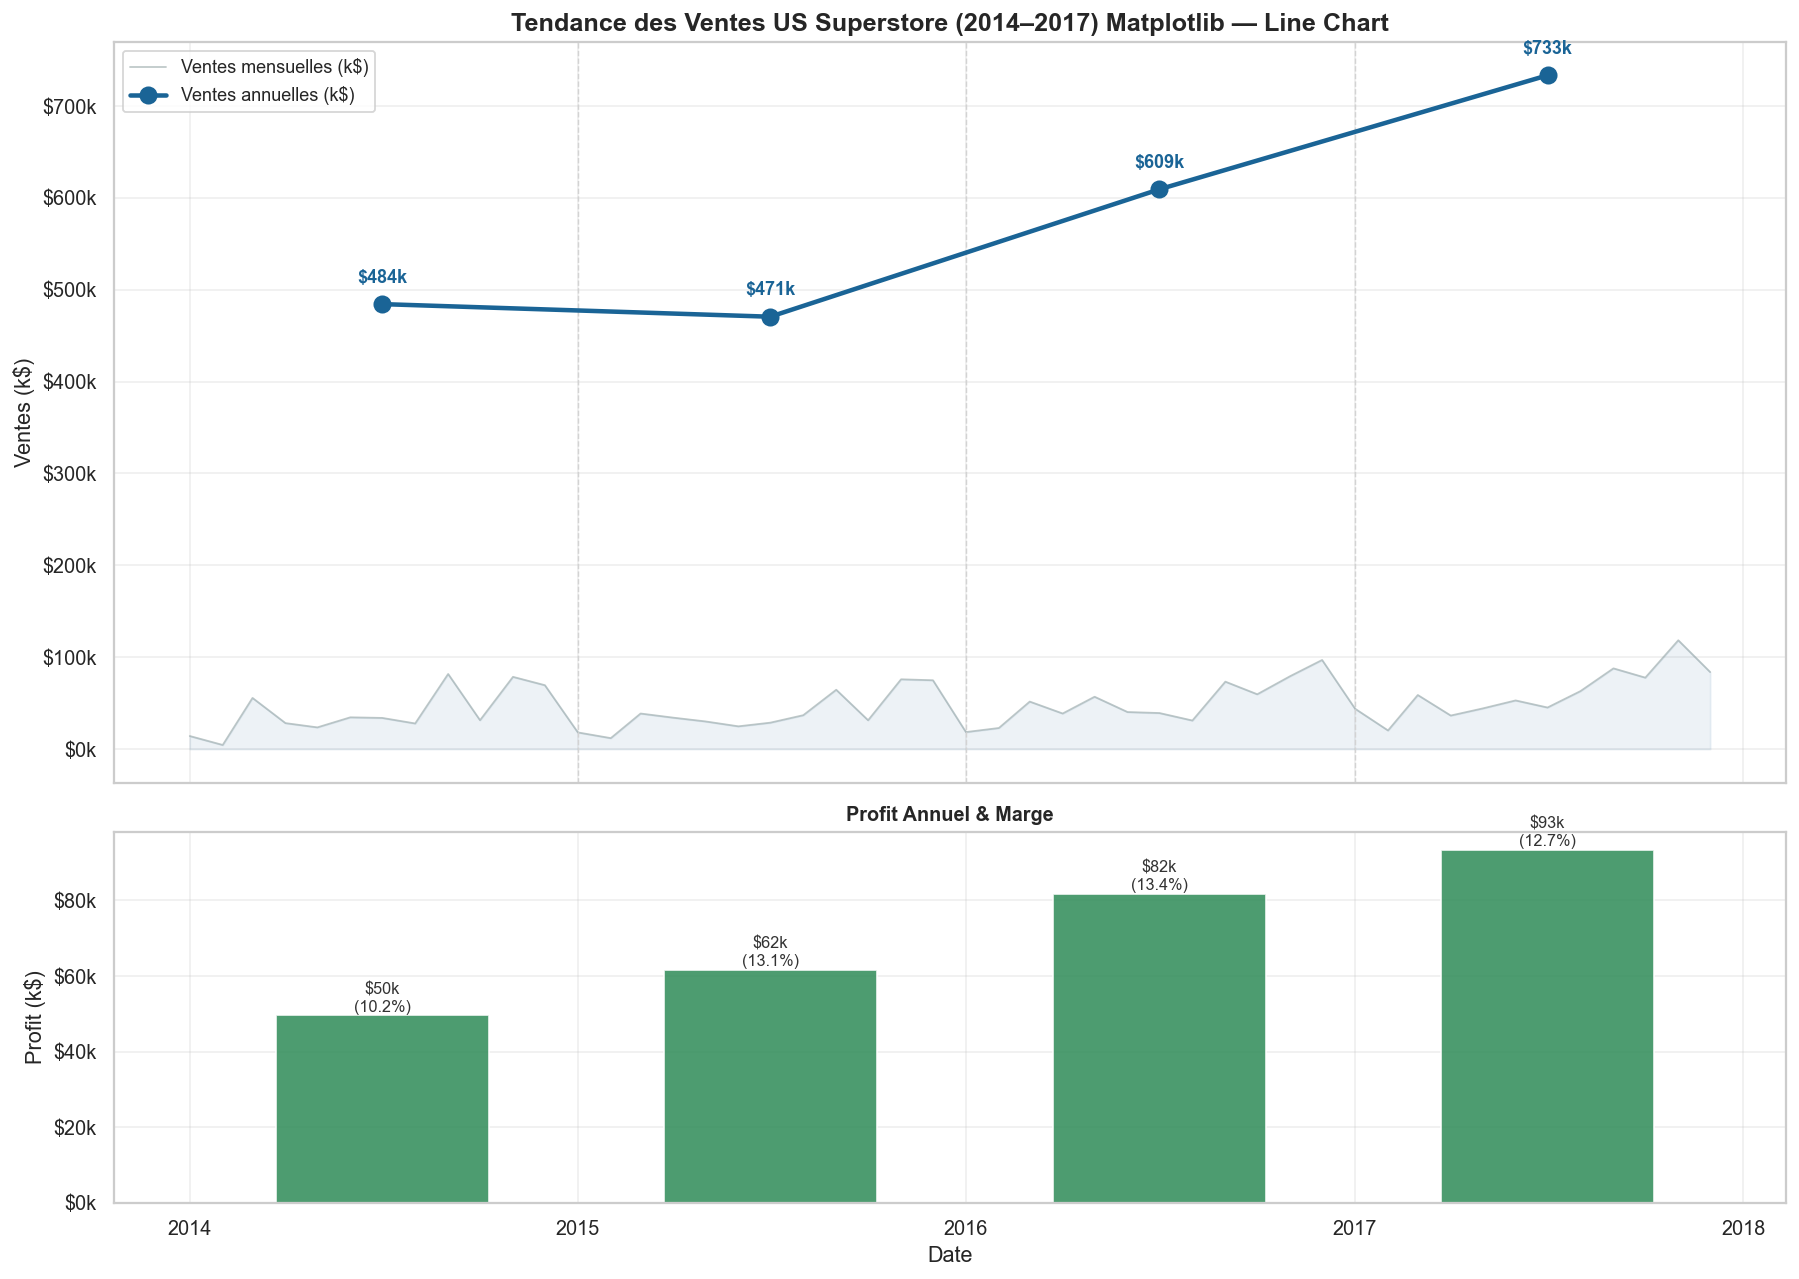

In [25]:
BLUE   = '#1a6496'
ORANGE = '#e07b39'
GREEN  = '#2e8b57'
RED    = '#c0392b'
GRAY   = '#95a5a6'

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})

# ── Graphique principal : courbe mensuelle + tendance annuelle ──
ax1 = axes[0]
# Courbe mensuelle (fond)
ax1.plot(monthly_sales['YearMonth_dt'], monthly_sales['Sales'] / 1e3,
         color=GRAY, linewidth=1, alpha=0.6, label='Ventes mensuelles (k$)')
# Remplissage sous la courbe
ax1.fill_between(monthly_sales['YearMonth_dt'], monthly_sales['Sales'] / 1e3,
                 alpha=0.08, color=BLUE)

# Points annuels + ligne
import matplotlib.dates as mdates
from datetime import datetime
annual_dates = [datetime(y, 7, 1) for y in annual_sales['Year']]
ax1.plot(annual_dates, annual_sales['Sales'] / 1e3,
         'o-', color=BLUE, linewidth=2.5, markersize=9,
         label='Ventes annuelles (k$)', zorder=5)

# Annotations ventes annuelles
for date, row in zip(annual_dates, annual_sales.itertuples()):
    ax1.annotate(f"${row.Sales/1e3:.0f}k",
                 xy=(date, row.Sales/1e3),
                 xytext=(0, 12), textcoords='offset points',
                 ha='center', fontsize=10, fontweight='bold', color=BLUE)

# Lignes verticales séparant les années
for year in annual_sales['Year'][1:]:
    ax1.axvline(datetime(year, 1, 1), color='lightgray', linestyle='--', linewidth=0.8)

ax1.set_ylabel('Ventes (k$)', fontsize=12)
ax1.set_title('Tendance des Ventes US Superstore (2014–2017) Matplotlib — Line Chart', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}k'))

# ── Graphique secondaire : profit ──────────────────────────────
ax2 = axes[1]
bar_colors = [GREEN if p >= 0 else RED for p in annual_sales['Profit']]
bars = ax2.bar(annual_dates, annual_sales['Profit'] / 1e3,
               color=bar_colors, width=200, alpha=0.85, edgecolor='white')
for bar, row in zip(bars, annual_sales.itertuples()):
    h = bar.get_height()
    ax2.text(
    bar.get_x() + bar.get_width()/2,
    h + 1,
    f"${h:.0f}k\n({row._5:.1f}%)",
    ha='center',
    fontsize=9,
    color='#333'
)

ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Profit (k$)', fontsize=12)
ax2.set_title('Profit Annuel & Marge', fontsize=11, fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}k'))

# Formatage axe X
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.show()


**📌 Insights :**
- Les ventes sont en **croissance constante** : +$228k entre 2014 et 2017 (+$184%)
- Le profit suit la même tendance — la marge reste stable entre **11% et 13%**
- Les pics de ventes apparaissent en **fin d'année** (Q4) — saisonnalité marquée
- 2017 est la meilleure année avec ~$733k de ventes


### 2B — Distribution des Ventes par État (Carte)

In [30]:
# Données par état pour la carte
state_sales = df.groupby('State').agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum')
).reset_index()
state_sales['Margin_%'] = (state_sales['Profit'] / state_sales['Sales'] * 100).round(2)

# Dictionnaire de mapping état → abréviation
state_abbrev = {
    'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA',
    'Colorado':'CO','Connecticut':'CT','Delaware':'DE','Florida':'FL','Georgia':'GA',
    'Hawaii':'HI','Idaho':'ID','Illinois':'IL','Indiana':'IN','Iowa':'IA',
    'Kansas':'KS','Kentucky':'KY','Louisiana':'LA','Maine':'ME','Maryland':'MD',
    'Massachusetts':'MA','Michigan':'MI','Minnesota':'MN','Mississippi':'MS',
    'Missouri':'MO','Montana':'MT','Nebraska':'NE','Nevada':'NV','New Hampshire':'NH',
    'New Jersey':'NJ','New Mexico':'NM','New York':'NY','North Carolina':'NC',
    'North Dakota':'ND','Ohio':'OH','Oklahoma':'OK','Oregon':'OR','Pennsylvania':'PA',
    'Rhode Island':'RI','South Carolina':'SC','South Dakota':'SD','Tennessee':'TN',
    'Texas':'TX','Utah':'UT','Vermont':'VT','Virginia':'VA','Washington':'WA',
    'West Virginia':'WV','Wisconsin':'WI','Wyoming':'WY','District of Columbia':'DC'
}
state_sales['Abbrev'] = state_sales['State'].map(state_abbrev)

try:
    import plotly.express as px
    HAS_PLOTLY = True
except ImportError:
    HAS_PLOTLY = False

if HAS_PLOTLY:
    fig = px.choropleth(
        state_sales,
        locations='Abbrev',
        locationmode='USA-states',
        color='Sales',
        hover_name='State',
        hover_data={'Sales': ':,.0f', 'Profit': ':,.0f', 'Margin_%': ':.1f', 'Abbrev': False},
        color_continuous_scale='Blues',
        scope='usa',
        title='Distribution des Ventes par État — US Superstore',
        labels={'Sales': 'Ventes ($)'}
    )
    fig.update_layout(
        title_font_size=16,
        geo=dict(showlakes=True, lakecolor='lightblue'),
        coloraxis_colorbar=dict(title='Ventes ($)', tickformat='$,.0f')
    )
    fig.show()
else:
    print("Plotly non installé — carte statique avec Matplotlib ci-dessous")


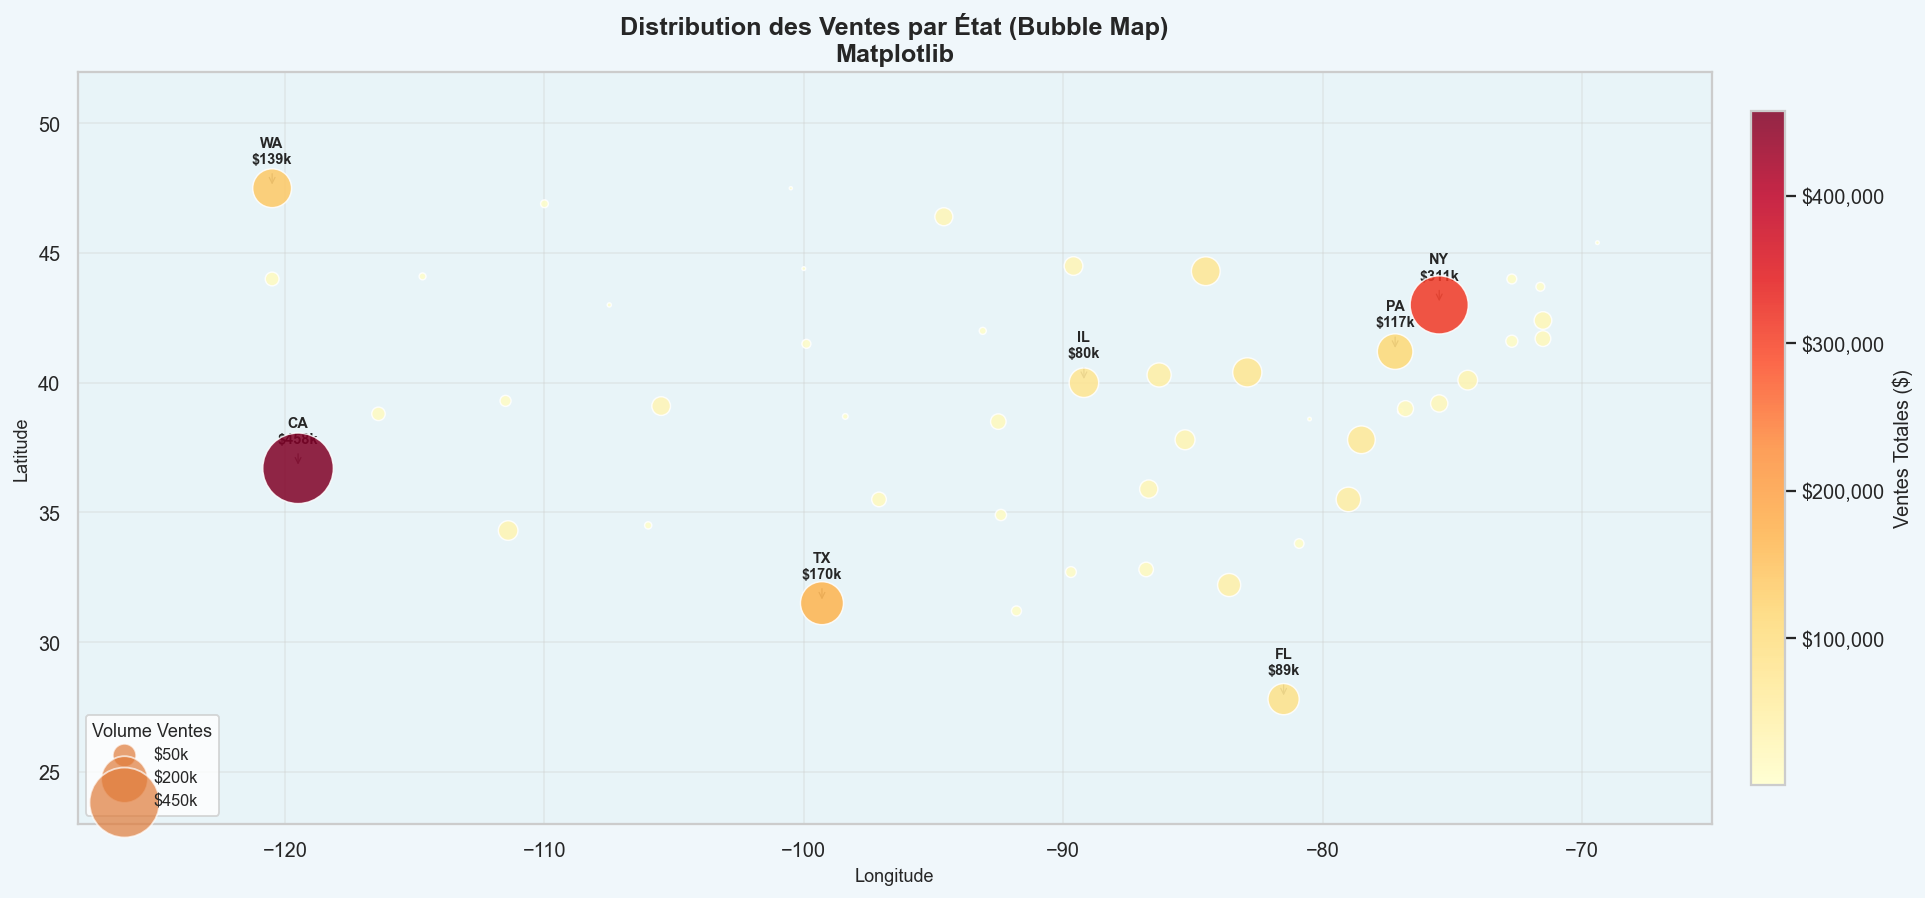

In [31]:
# ── Carte statique Matplotlib (fallback + toujours utile) ──────
# Bubble map sur grille de coordonnées approximatives des états
state_coords = {
    'California':(-119.5,36.7),'New York':(-75.5,43.0),'Texas':(-99.3,31.5),
    'Washington':(-120.5,47.5),'Pennsylvania':(-77.2,41.2),'Florida':(-81.5,27.8),
    'Illinois':(-89.2,40.0),'Ohio':(-82.9,40.4),'Michigan':(-84.5,44.3),
    'North Carolina':(-79.0,35.5),'Georgia':(-83.6,32.2),'Virginia':(-78.5,37.8),
    'Indiana':(-86.3,40.3),'Tennessee':(-86.7,35.9),'Wisconsin':(-89.6,44.5),
    'Colorado':(-105.5,39.1),'Minnesota':(-94.6,46.4),'Arizona':(-111.4,34.3),
    'Missouri':(-92.5,38.5),'Connecticut':(-72.7,41.6),'New Jersey':(-74.4,40.1),
    'Oregon':(-120.5,44.0),'Alabama':(-86.8,32.8),'Massachusetts':(-71.5,42.4),
    'Louisiana':(-91.8,31.2),'Maryland':(-76.8,39.0),'Kentucky':(-85.3,37.8),
    'Oklahoma':(-97.1,35.5),'Arkansas':(-92.4,34.9),'Nevada':(-116.4,38.8),
    'South Carolina':(-80.9,33.8),'Utah':(-111.5,39.3),'Nebraska':(-99.9,41.5),
    'Kansas':(-98.4,38.7),'Iowa':(-93.1,42.0),'Mississippi':(-89.7,32.7),
    'New Mexico':(-106.0,34.5),'Idaho':(-114.7,44.1),'Montana':(-110.0,46.9),
    'New Hampshire':(-71.6,43.7),'Maine':(-69.4,45.4),'Vermont':(-72.7,44.0),
    'Wyoming':(-107.5,43.0),'West Virginia':(-80.5,38.6),'Delaware':(-75.5,39.2),
    'Rhode Island':(-71.5,41.7),'District of Columbia':(-77.0,38.9),
    'North Dakota':(-100.5,47.5),'South Dakota':(-100.0,44.4),'Alaska':(-153.0,64.0)
}

state_map = state_sales[state_sales['State'].isin(state_coords)].copy()
state_map['lon'] = state_map['State'].map(lambda s: state_coords[s][0])
state_map['lat'] = state_map['State'].map(lambda s: state_coords[s][1])

fig, ax = plt.subplots(figsize=(16, 9))
ax.set_facecolor('#e8f4f8')
fig.patch.set_facecolor('#f0f7fb')

# Fond US simplifié (rectangle)
ax.set_xlim(-128, -65); ax.set_ylim(23, 52)
ax.set_aspect('equal')

sc = ax.scatter(
    state_map['lon'], state_map['lat'],
    s=state_map['Sales'] / 300,
    c=state_map['Sales'],
    cmap='YlOrRd',
    alpha=0.85,
    edgecolors='white',
    linewidths=0.8,
    zorder=5
)

# Annotations des états principaux
for _, row in state_map[state_map['Sales'] > 80000].iterrows():
    ax.annotate(
        f"{state_abbrev.get(row['State'], '')}\n${row['Sales']/1e3:.0f}k",
        xy=(row['lon'], row['lat']),
        xytext=(0, 14), textcoords='offset points',
        ha='center', fontsize=8, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.7)
    )

cbar = plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Ventes Totales ($)', fontsize=11)
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

ax.set_title('Distribution des Ventes par État (Bubble Map)\nMatplotlib', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)

# Légende taille
for size_val, label in [(50000,'$50k'), (200000,'$200k'), (450000,'$450k')]:
    ax.scatter([], [], s=size_val/300, c='#e07b39', alpha=0.7, label=label, edgecolors='white')
ax.legend(title='Volume Ventes', fontsize=9, title_fontsize=10, loc='lower left')

plt.tight_layout()
plt.show()


**📌 Insights Carte :**
- La **côte Est** (New York, Pennsylvanie, Géorgie) et la **côte Ouest** (Californie, Washington) concentrent l'essentiel des ventes
- La **Californie** est de loin le plus grand marché géographique
- Le centre des États-Unis (Montana, Wyoming, Dakotas) est quasi-absent
- Opportunité : **Midwest & Sud** sous-exploités


---
## 🎨 Partie 3 — Visualisation avec Seaborn

> Seaborn est une librairie de **haut niveau** construite sur Matplotlib.
> Elle simplifie la création de graphiques statistiques élégants avec moins de code.


### 3A — Top 10 Produits par Ventes (Bar Chart Seaborn)

In [32]:
# Top 10 produits par ventes
top10_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top10_products['Product_Short'] = top10_products['Product Name'].apply(
    lambda x: x[:35] + '…' if len(x) > 35 else x
)

print("Top 10 Produits :")
print(top10_products[['Product Name','Sales']].to_string(index=False))


Top 10 Produits :
                                                               Product Name     Sales
                                      Canon imageCLASS 2200 Advanced Copier 61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind 27453.384
                      Cisco TelePresence System EX90 Videoconferencing Unit 22638.480
                               HON 5400 Series Task Chairs for Big and Tall 21870.576
                                 GBC DocuBind TL300 Electric Binding System 19823.479
                           GBC Ibimaster 500 Manual ProClick Binding System 19024.500
                                       Hewlett Packard LaserJet 3310 Copier 18839.686
                  HP Designjet T520 Inkjet Large Format Printer - 24" Color 18374.895
                                  GBC DocuBind P400 Electric Binding System 17965.068
                                High Speed Automatic Electric Letter Opener 17030.312


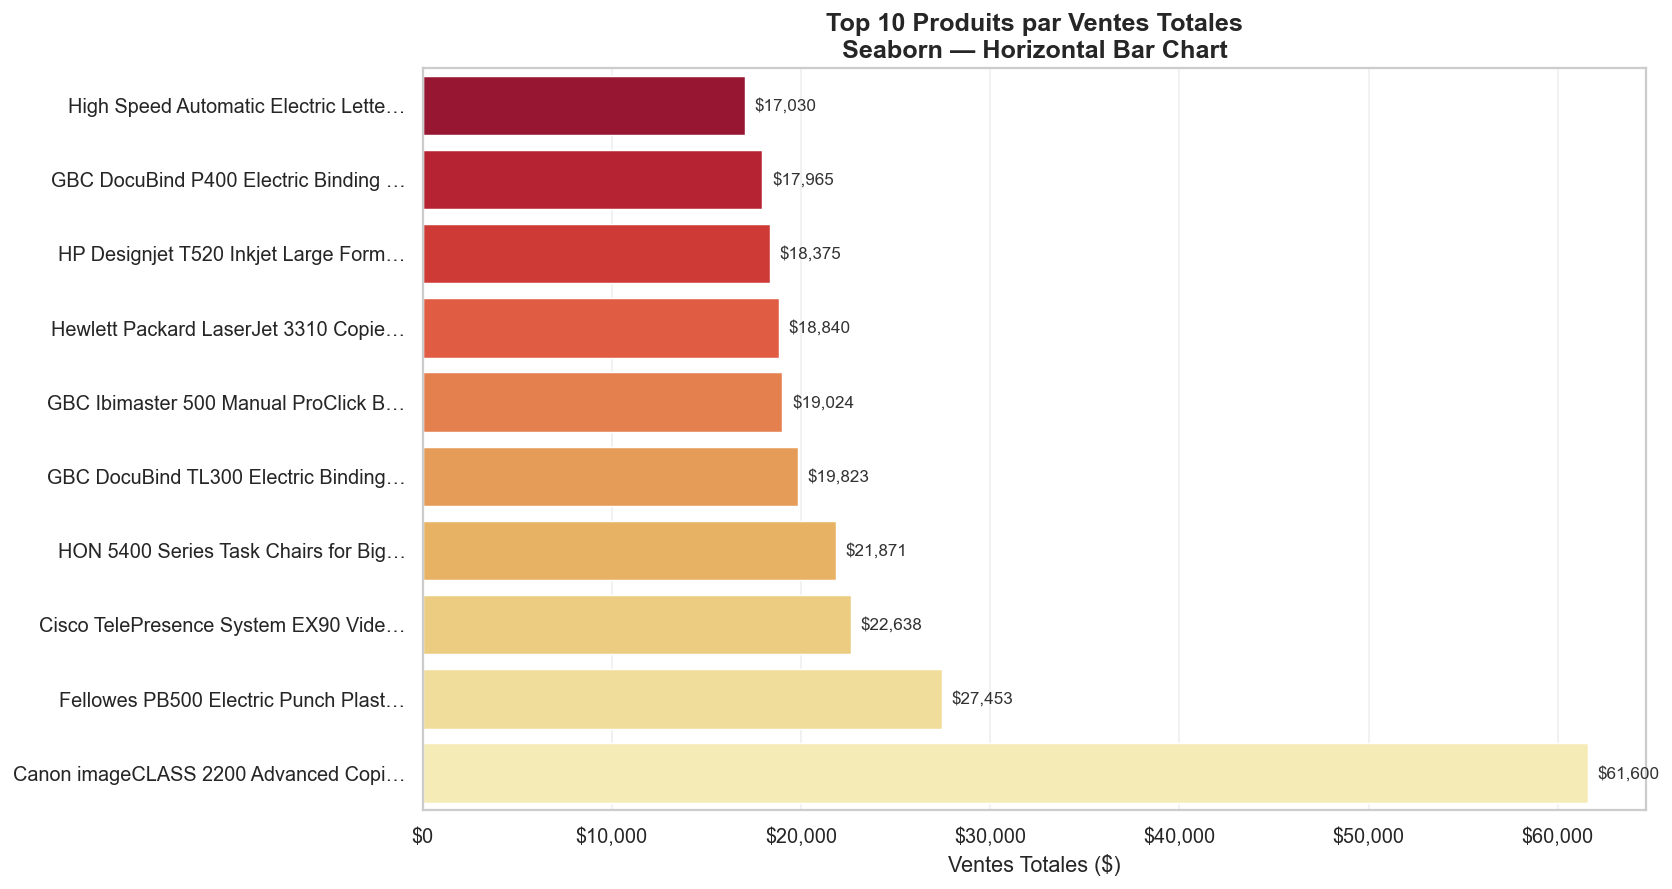

In [33]:
fig, ax = plt.subplots(figsize=(13, 7))

palette = sns.color_palette('YlOrRd_r', n_colors=10)

bars = sns.barplot(
    data=top10_products,
    y='Product_Short',
    x='Sales',
    palette=palette,
    order=top10_products.sort_values('Sales', ascending=True)['Product_Short'],
    ax=ax,
    edgecolor='white',
    linewidth=0.8
)

# Annotations valeurs
for bar in ax.patches:
    w = bar.get_width()
    ax.text(w + 500, bar.get_y() + bar.get_height() / 2,
            f'${w:,.0f}', va='center', fontsize=9.5, color='#333')

ax.set_xlabel('Ventes Totales ($)', fontsize=12)
ax.set_ylabel('')
ax.set_title('Top 10 Produits par Ventes Totales\nSeaborn — Horizontal Bar Chart',
             fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

plt.tight_layout()
plt.show()


**📌 Insights :**
- Le **Canon imageCLASS 2200** domine avec ~$60k de ventes — quasi le double du 2ème
- Les **téléphones** (Nokia, Motorola) et **machines de bureau** (Cisco) sont très représentés
- Les top produits appartiennent aux catégories **Technology** et **Office Supplies**
- Ces produits doivent bénéficier d'une visibilité maximale dans les campagnes marketing


### 3B — Relation Profit / Remise (Scatter Plot Seaborn)

In [35]:
# Préparation : sample pour lisibilité (ou tout si dataset raisonnable)
scatter_df = df.copy()
scatter_df['Profit_Sign'] = scatter_df['Profit'].apply(lambda x: 'Profitable' if x >= 0 else 'Déficitaire')

print(f"Transactions profitables  : {(scatter_df['Profit'] >= 0).sum():,} ({(scatter_df['Profit'] >= 0).mean()*100:.1f}%)")
print(f"Transactions déficitaires : {(scatter_df['Profit'] < 0).sum():,} ({(scatter_df['Profit'] < 0).mean()*100:.1f}%)")
print(f"\nCorr. Discount / Profit : {df['Discount'].corr(df['Profit']):.3f}")


Transactions profitables  : 8,123 (81.3%)
Transactions déficitaires : 1,871 (18.7%)

Corr. Discount / Profit : -0.219


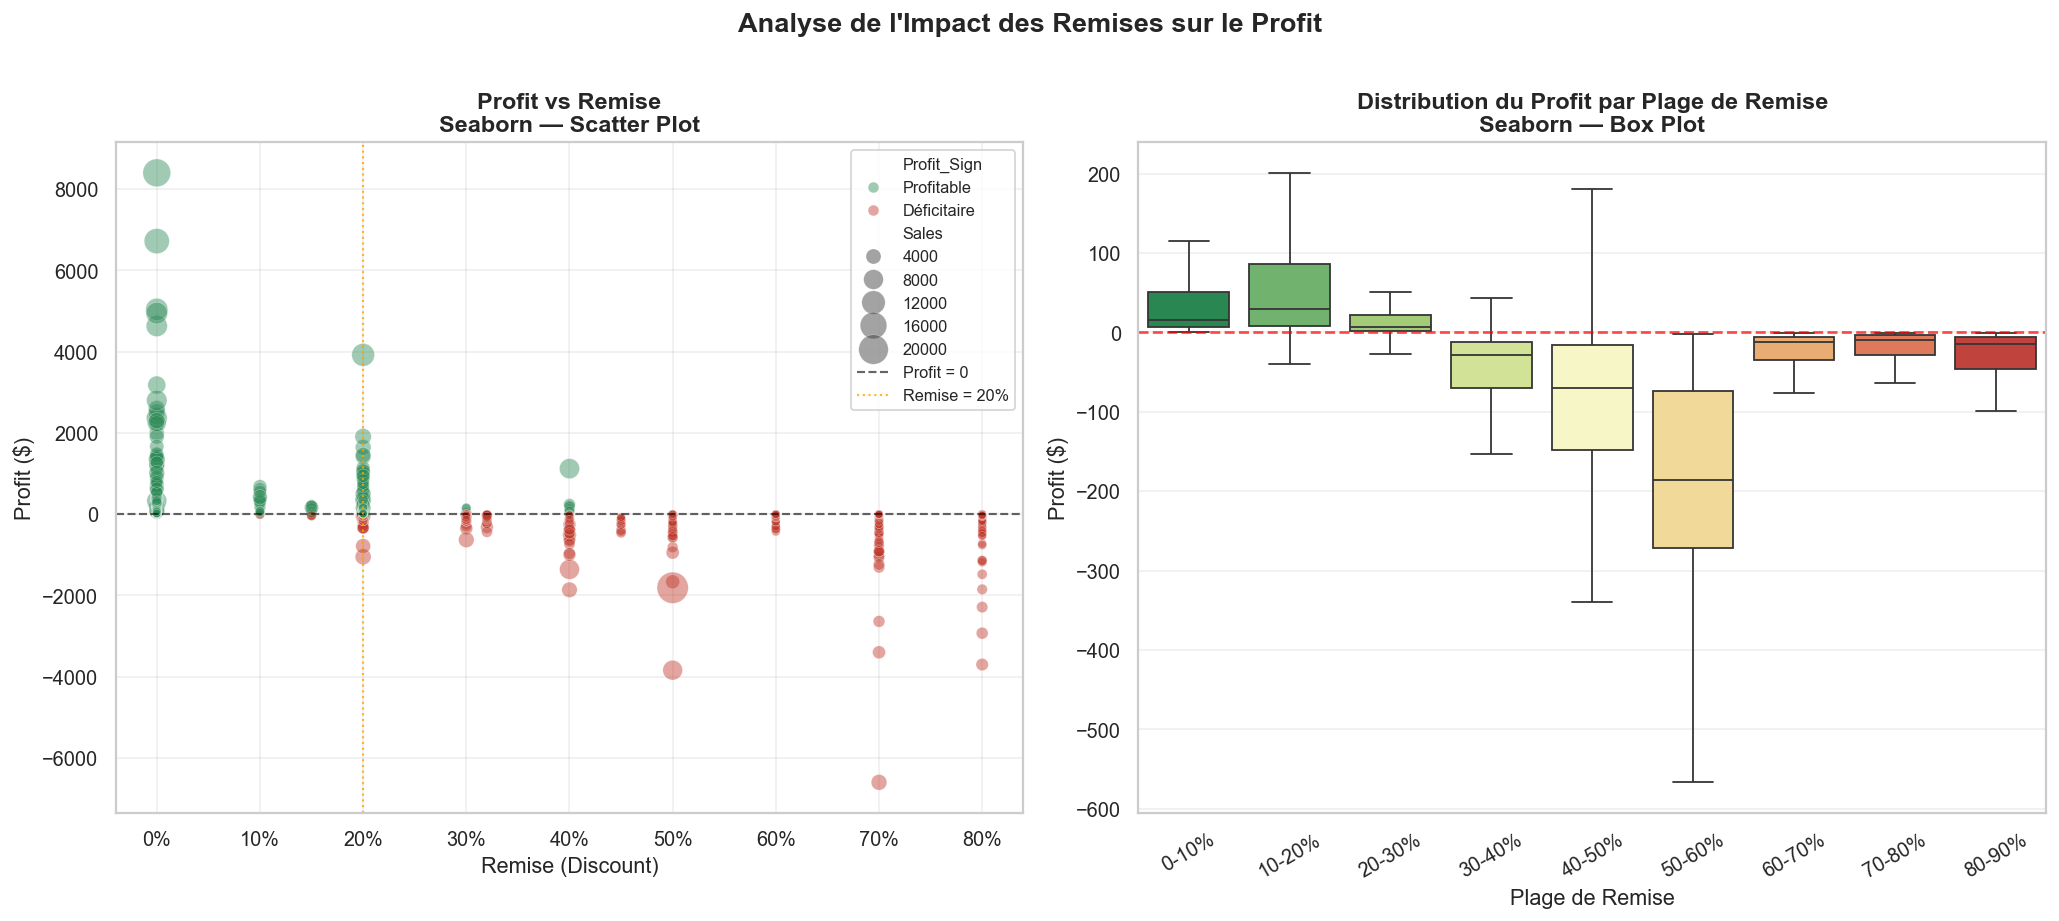

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Scatter principal ───────────────────────────────────────────
ax = axes[0]
palette_sign = {'Profitable': '#2e8b57', 'Déficitaire': '#c0392b'}

sns.scatterplot(
    data=scatter_df,
    x='Discount',
    y='Profit',
    hue='Profit_Sign',
    palette=palette_sign,
    size='Sales',
    sizes=(20, 300),
    alpha=0.45,
    edgecolors='white',
    linewidths=0.3,
    ax=ax
)
ax.axhline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.6, label='Profit = 0')
ax.axvline(0.2, color='orange', linewidth=1.2, linestyle=':', alpha=0.8, label='Remise = 20%')

ax.set_xlabel('Remise (Discount)', fontsize=12)
ax.set_ylabel('Profit ($)', fontsize=12)
ax.set_title('Profit vs Remise\nSeaborn — Scatter Plot', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=9)

# ── Boxplot profit par plage de remise ─────────────────────────
ax = axes[1]
bins   = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
labels = ['0-10%','10-20%','20-30%','30-40%','40-50%','50-60%','60-70%','70-80%','80-90%']
scatter_df['Discount_Range'] = pd.cut(scatter_df['Discount'], bins=bins, labels=labels, right=False)

disc_df = scatter_df.dropna(subset=['Discount_Range'])
order_labels = [l for l in labels if l in disc_df['Discount_Range'].cat.categories]

sns.boxplot(
    data=disc_df,
    x='Discount_Range',
    y='Profit',
    palette='RdYlGn_r',
    order=order_labels,
    showfliers=False,
    ax=ax
)
ax.axhline(0, color='red', linewidth=1.5, linestyle='--', alpha=0.7)
ax.set_xlabel('Plage de Remise', fontsize=12)
ax.set_ylabel('Profit ($)', fontsize=12)
ax.set_title('Distribution du Profit par Plage de Remise\nSeaborn — Box Plot', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)

plt.suptitle('Analyse de l\'Impact des Remises sur le Profit', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**📌 Insights :**
- **Corrélation négative forte** entre remise et profit : plus la remise est élevée, plus le profit chute
- Au-delà de **20% de remise**, la majorité des transactions deviennent **déficitaires**
- Au-delà de **40% de remise**, la médiane du profit est clairement négative
- **Recommandation** : plafonner les remises à 20% maximum — les remises agressives détruisent de la valeur

> 💡 Le scatter plot Seaborn permet de visualiser en une seule image la relation, la densité et la taille relative des transactions.


---
## ⚖️ Partie 4 — Analyse Comparative : Matplotlib vs Seaborn


In [37]:
# Tableau de comparaison affiché via un graphique texte
comparison = {
    'Critère': [
        'Niveau d\'abstraction',
        'Quantité de code',
        'Personnalisation',
        'Graphiques statistiques',
        'Intégration Pandas',
        'Interactivité',
        'Courbe d\'apprentissage',
        'Esthétique par défaut',
        'Cas d\'usage idéal',
    ],
    'Matplotlib': [
        'Bas niveau (contrôle total)',
        'Verbeux (~2–3× plus de lignes)',
        'Maximale (chaque pixel)',
        'Possible mais manuel',
        'Bonne (via ax)',
        'Limitée (nécessite Plotly/Bokeh)',
        'Raide — nombreuses options',
        'Basique sans effort',
        'Figures sur mesure, dashboards',
    ],
    'Seaborn': [
        'Haut niveau (orienté stats)',
        'Concis (moins de code)',
        'Bonne mais moins fine',
        'Native et riche',
        'Excellente (DataFrames directs)',
        'Non native',
        'Douce — syntaxe intuitive',
        'Soignée dès la 1ère ligne',
        'Exploration, stats, EDA rapide',
    ]
}

df_comp = pd.DataFrame(comparison)
print(df_comp.to_string(index=False))


                Critère                       Matplotlib                         Seaborn
   Niveau d'abstraction      Bas niveau (contrôle total)     Haut niveau (orienté stats)
       Quantité de code   Verbeux (~2–3× plus de lignes)          Concis (moins de code)
       Personnalisation          Maximale (chaque pixel)           Bonne mais moins fine
Graphiques statistiques             Possible mais manuel                 Native et riche
     Intégration Pandas                   Bonne (via ax) Excellente (DataFrames directs)
          Interactivité Limitée (nécessite Plotly/Bokeh)                      Non native
 Courbe d'apprentissage       Raide — nombreuses options       Douce — syntaxe intuitive
  Esthétique par défaut              Basique sans effort       Soignée dès la 1ère ligne
      Cas d'usage idéal   Figures sur mesure, dashboards  Exploration, stats, EDA rapide


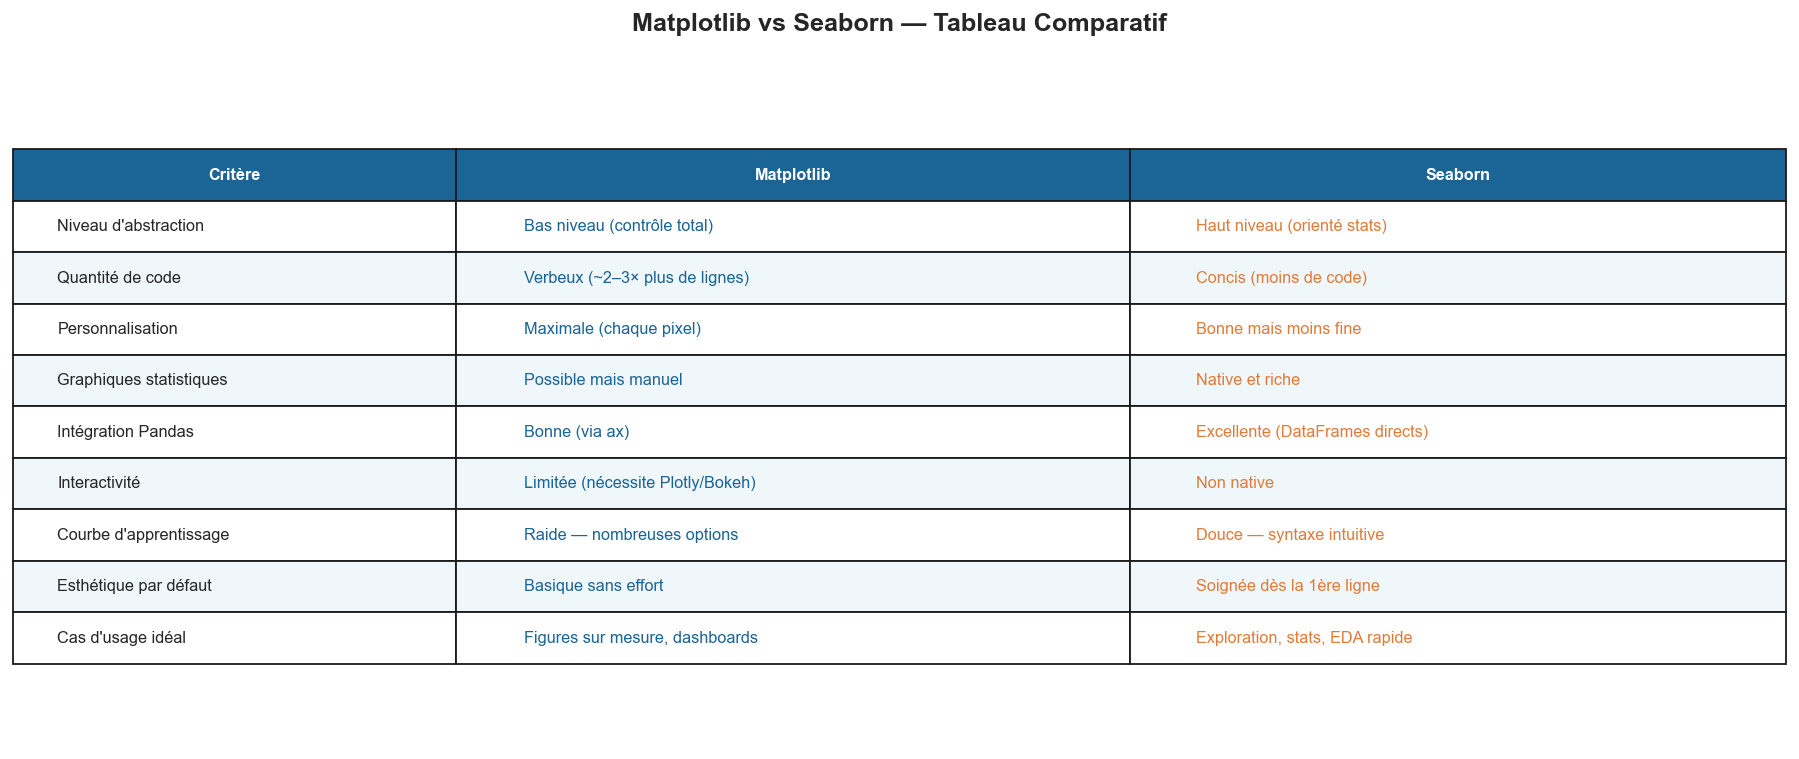

In [38]:
# Visualisation comparative sous forme de tableau graphique
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

table_data = [df_comp.columns.tolist()] + df_comp.values.tolist()
table = ax.table(
    cellText=df_comp.values,
    colLabels=df_comp.columns,
    cellLoc='left',
    loc='center',
    colWidths=[0.25, 0.38, 0.37]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.1)

# Style header
for j in range(3):
    table[(0, j)].set_facecolor('#1a6496')
    table[(0, j)].set_text_props(color='white', fontweight='bold')

# Alternance couleurs lignes
for i in range(1, len(df_comp)+1):
    clr = '#f0f7fb' if i % 2 == 0 else 'white'
    for j in range(3):
        table[(i, j)].set_facecolor(clr)
        if j == 1:
            table[(i, j)].set_text_props(color='#1a6496')
        elif j == 2:
            table[(i, j)].set_text_props(color='#e07b39')

ax.set_title('Matplotlib vs Seaborn — Tableau Comparatif',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


### 🔍 Observations et Conclusions

#### Matplotlib
- **Points forts** : Contrôle absolu sur le rendu (axes, annotations, couleurs, sous-graphiques complexes). Indispensable pour des figures sur-mesure comme les cartes bubble ou les graphiques multi-panneaux.
- **Points faibles** : Code verbeux, nécessite de gérer manuellement les détails esthétiques. Moins adapté à l'exploration rapide de données.

#### Seaborn  
- **Points forts** : Syntaxe très concise, esthétique soignée par défaut, natif pour les graphiques statistiques (boxplot, violin, heatmap, pairplot). Idéal pour l'EDA (Exploratory Data Analysis).
- **Points faibles** : Moins de contrôle fin, pas d'interactivité native.

#### Recommandation d'usage
| Phase | Outil recommandé |
|-------|-----------------|
| Exploration rapide / EDA | **Seaborn** |
| Rapport / Publication | **Seaborn** (base) + **Matplotlib** (finitions) |
| Dashboard interactif | **Plotly** ou **Bokeh** |
| Figure très personnalisée | **Matplotlib** |

> **Conclusion :** Les deux librairies sont **complémentaires**, pas concurrentes.
> La meilleure pratique est d'utiliser **Seaborn pour le prototype** et **Matplotlib pour la finition**.


---
## 🎯 Partie 5 — Synthèse des Insights & Recommandations

### Insights Clés

1. **Croissance soutenue** : Les ventes ont augmenté de +184% entre 2014 et 2017, avec une saisonnalité marquée en Q4.

2. **Concentration géographique** : Californie et New York représentent ~35% des ventes totales.

3. **Remises destructrices** : Au-delà de 20% de remise, la plupart des transactions génèrent des pertes. C'est la cause principale des états/villes déficitaires.

4. **Top produits** : Le Canon imageCLASS 2200 est le produit phare — à mettre en avant systématiquement.

5. **Pareto des clients** : ~40% des clients génèrent 80% du profit — les fidéliser est la priorité.

### Actions Recommandées

| Priorité | Action | Impact attendu |
|----------|--------|---------------|
| 🔴 Urgent | Plafonner les remises à 20% | Retour à la rentabilité au Texas, Ohio |
| 🟠 Fort | Programme fidélité clients VIP | Sécuriser 80% du profit |
| 🟡 Moyen | Renforcer la présence Californie & NY | Maximiser le marché n°1 |
| 🟢 Long terme | Explorer le Midwest (sous-pénétré) | Nouveaux marchés |
